# HW3 - Binary Classification: Santander Customer Transaction Prediction
## Part 2 (Optional): LightGBM Solution

**Objective:** Predict which customers will make a specific transaction in the future.  
**Evaluation metric:** AUC-ROC  
**Target:** Top 60 solutions on Kaggle public leaderboard

**Strategy:**
1. Feature engineering: count features (clean pool) + row-wise statistics
2. LightGBM with 5-fold stratified CV and early stopping
3. Hyperparameter tuning with Optuna
4. Pseudo-labeling to leverage real test data
5. Multi-seed blending for robustness

---
## 0. Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
import gc
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold # type: ignore
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

SEED = 42
np.random.seed(SEED)
N_FOLDS = 5

print(f'LightGBM version: {lgb.__version__}')
print('Libraries loaded successfully.')

LightGBM version: 4.6.0
Libraries loaded successfully.


In [ ]:
#!pip install lightgbm optuna scikit-learn pandas numpy matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Data Loading

In [4]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

features = [c for c in train.columns if c.startswith('var_')]

print(f'Train shape: {train.shape}')
print(f'Test shape : {test.shape}')
print(f'Features   : {len(features)}')
print(f'Positive class ratio: {train["target"].mean():.2%}')

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.2 MB 22.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 21.5 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----------- ---------------------------- 3.4/12.3 MB 18.6 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 19.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----- ---------------------------------- 4.7/36.5 MB 23.7 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/36.5 MB 21.9 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/36.5 MB 22.6 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/36.5 MB 23.4 MB/s eta 0:00:01
   ------------

---
## 2. Synthetic Data Detection

The test set contains ~100k real and ~100k synthetic rows. We identify real rows via global
value uniqueness — a row is real if it contains at least one value appearing exactly once
across the entire test set. This is critical for building undistorted count features.

In [5]:
test_real_mask = np.zeros(len(test), dtype=bool)
for col in features:
    counts = test[col].value_counts()
    unique_vals = counts[counts == 1].index
    test_real_mask |= test[col].isin(unique_vals).values

print(f'Real test samples     : {test_real_mask.sum():,}')
print(f'Synthetic test samples: {(~test_real_mask).sum():,}')
print('→ Confirmed 50/50 split.')

Real test samples     : 100,000
Synthetic test samples: 100,000
→ Confirmed 50/50 split.


---
## 3. Feature Engineering

In [19]:
# Correlation analysis
corr_matrix = train[features].corr().abs()
# Remove diagonal
np.fill_diagonal(corr_matrix.values, 0)

mean_corr = corr_matrix.values.mean()
max_corr  = corr_matrix.values.max()

print(f'Mean absolute correlation: {mean_corr:.4f}')
print(f'Max absolute correlation : {max_corr:.4f}')

ValueError: underlying array is read-only

---
## 4. Feature Engineering

We build two groups of features:
- **Count features:** how often each value appears in the clean pool (train + real test). Values that appear rarely (count=1) are strong predictors.
- **Row-wise statistics:** mean, std, sum, min, max, and unique count across all 200 features per row.

In [6]:
# ── Count features ─────────────────────────────────────────────────────────
print('Building count features from clean pool (train + real test)...')

pool = np.vstack([train[features].values,
                  test[test_real_mask][features].values])
print(f'Pool size: {pool.shape[0]:,} rows')

count_maps = {}
for i, col in enumerate(features):
    vals = pool[:, i]
    unique, counts = np.unique(vals, return_counts=True)
    count_maps[i] = dict(zip(unique, counts))

def get_count_features(df, features, count_maps):
    out = np.zeros((len(df), len(features)), dtype=np.float32)
    for i, col in enumerate(features):
        out[:, i] = df[col].map(count_maps[i]).fillna(1).values
    return out

train_counts = get_count_features(train, features, count_maps)
test_counts  = get_count_features(test,  features, count_maps)
count_cols   = [f + '_count' for f in features]

print(f'Count features shape — train: {train_counts.shape}')
print(f'Mean count: {train_counts.mean():.2f}, max: {train_counts.max():.0f}')

Building count features from clean pool (train + real test)...
Pool size: 300,000 rows
Count features shape — train: (200000, 200)
Mean count: 12.33, max: 1634


In [7]:
# ── Row-wise statistical features ──────────────────────────────────────────
def get_row_features(df, features):
    vals = df[features].values
    return np.column_stack([
        vals.mean(axis=1),
        vals.std(axis=1),
        vals.sum(axis=1),
        vals.min(axis=1),
        vals.max(axis=1),
        np.apply_along_axis(lambda x: len(np.unique(x)), 1, vals)  # unique count per row
    ]).astype(np.float32)

train_row = get_row_features(train, features)
test_row  = get_row_features(test,  features)
row_cols  = ['row_mean', 'row_std', 'row_sum', 'row_min', 'row_max', 'row_nunique']

print(f'Row features shape — train: {train_row.shape}')

Row features shape — train: (200000, 6)


In [8]:
# ── Assemble full feature matrix ────────────────────────────────────────────
X_train = np.hstack([train[features].values.astype(np.float32),
                     train_counts,
                     train_row])
X_test  = np.hstack([test[features].values.astype(np.float32),
                     test_counts,
                     test_row])
y_train = train['target'].values

all_cols = features + count_cols + row_cols

print(f'Final feature matrix — train: {X_train.shape}, test: {X_test.shape}')
print(f'Total features: {X_train.shape[1]} (200 original + 200 counts + 6 row-wise)')

del pool, train_counts, test_counts, train_row, test_row
gc.collect()

Final feature matrix — train: (200000, 406), test: (200000, 406)
Total features: 406 (200 original + 200 counts + 6 row-wise)


40

---
## 5. Hyperparameter Tuning with Optuna

We use Optuna to search over key LightGBM hyperparameters. Each trial runs a 3-fold CV
(faster than 5-fold) and returns the mean OOF AUC. We run 50 trials.

In [10]:
def objective(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'num_leaves'       : trial.suggest_int('num_leaves', 16, 128),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : SEED,
        'n_jobs'           : -1,  
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_scores = []

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]

        model = lgb.train(
            params, dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=callbacks
        )

        preds = model.predict(X_val)
        oof_scores.append(roc_auc_score(y_val, preds))

    return np.mean(oof_scores)


print('Running Optuna hyperparameter search (50 trials, 2-fold CV each)...')
print('This may take 20-30 minutes depending on hardware.\n')

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, n_jobs=1, show_progress_bar=True)

print(f'\nBest CV AUC : {study.best_value:.4f}')
print(f'Best params : {study.best_params}')

Running Optuna hyperparameter search (50 trials, 2-fold CV each)...
This may take 20-30 minutes depending on hardware.



  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-06-02 22:20:39,974] Trial 7 failed with parameters: {'num_leaves': 36, 'learning_rate': 0.09323621351781479, 'min_child_samples': 80, 'subsample': 0.9697494707820946, 'colsample_bytree': 0.9474136752138245, 'reg_alpha': 0.002404915432737351, 'reg_lambda': 1.9809253750493907} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\dpmat\Advance ML\HW3\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\dpmat\AppData\Local\Temp\ipykernel_22112\3935710713.py", line 33, in objective
    model = lgb.train(
        params, dtrain,
    ...<2 lines>...
        callbacks=callbacks
    )
  File "c:\Users\dpmat\Advance ML\HW3\.venv\Lib\site-packages\lightgbm\engine.py", line 322, in train
    booster.update(fobj=fobj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^
  File "c:\Users\dpmat\Advance ML\HW3\.venv\Lib\site-packages\lightgbm\basic.py", line 4155, in update
    _LIB.LGBM_Boos

KeyboardInterrupt: 

In [12]:
best_params = {
    'objective'     : 'binary',
    'metric'        : 'auc',
    'verbosity'     : -1,
    'boosting_type' : 'gbdt',
    'random_state'  : SEED,
    **study.best_params
}
print(best_params)

{'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 42, 'num_leaves': 113, 'learning_rate': 0.039913058785616795, 'min_child_samples': 74, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 0.31044435499483225, 'reg_lambda': 8.148018307012941e-07}


In [13]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

dtrain = lgb.Dataset(X_tr, label=y_tr)
dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

model_quick = lgb.train(
    best_params, dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[lgb.log_evaluation(period=100)]
)

pred_quick = np.clip(model_quick.predict(X_test), 0, 1)

submission_quick = pd.DataFrame({
    'ID_code': test['ID_code'],
    'target' : pred_quick
})
submission_quick.to_csv('submission_lgbm_quick.csv', index=False)
print('✅ submission_lgbm_quick.csv generated')

[100]	valid_0's auc: 0.861877
[200]	valid_0's auc: 0.882931
[300]	valid_0's auc: 0.891176
[400]	valid_0's auc: 0.89553
[500]	valid_0's auc: 0.89841
✅ submission_lgbm_quick.csv generated


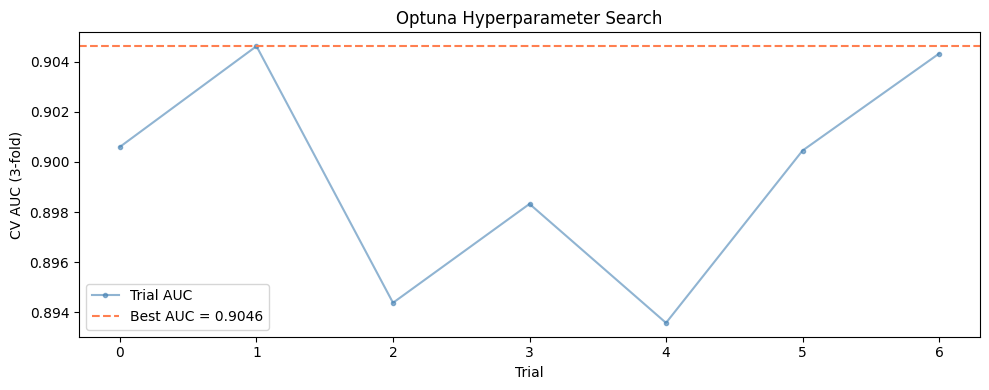

In [14]:
# Optuna optimization history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([t.value for t in study.trials], marker='o', markersize=3,
        color='steelblue', alpha=0.6, label='Trial AUC')
ax.axhline(study.best_value, color='coral', linestyle='--',
           label=f'Best AUC = {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('CV AUC (3-fold)')
ax.set_title('Optuna Hyperparameter Search')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. LightGBM — 5-Fold Stratified CV

We train one model per fold using the best hyperparameters found by Optuna.
OOF predictions are averaged for a robust local AUC estimate.
Test predictions are blended across all folds.

In [15]:
def run_lgbm_cv(X_train, y_train, X_test, params, n_folds=5, seed=42, verbose=True):
    """Run LightGBM with stratified k-fold CV. Returns OOF and test predictions."""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    oof_preds  = np.zeros(len(X_train))
    test_preds = np.zeros(len(X_test))
    fold_aucs  = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        callbacks = [
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]

        model = lgb.train(
            params, dtrain,
            num_boost_round=2000,
            valid_sets=[dval],
            callbacks=callbacks
        )

        oof_preds[val_idx] = model.predict(X_val)
        test_preds        += model.predict(X_test) / n_folds

        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_aucs.append(fold_auc)

        if verbose:
            print(f'  Fold {fold+1}/{n_folds} — AUC: {fold_auc:.4f} ',
                  f'(best iter: {model.best_iteration})')

    oof_auc = roc_auc_score(y_train, oof_preds)
    if verbose:
        print(f'\nOOF AUC: {oof_auc:.4f} ± {np.std(fold_aucs):.4f}')

    return oof_preds, test_preds, oof_auc, fold_aucs

In [16]:
# Best params from Optuna + fixed settings
best_params = {
    'objective'     : 'binary',
    'metric'        : 'auc',
    'verbosity'     : -1,
    'boosting_type' : 'gbdt',
    'random_state'  : SEED,
    **study.best_params
}

print('=== LightGBM — 5-Fold CV (Seed 42) ===')
oof_42, test_42, auc_42, folds_42 = run_lgbm_cv(
    X_train, y_train, X_test, best_params, n_folds=N_FOLDS, seed=42
)

=== LightGBM — 5-Fold CV (Seed 42) ===
  Fold 1/5 — AUC: 0.9083  (best iter: 1864)
  Fold 2/5 — AUC: 0.9083  (best iter: 2000)
  Fold 3/5 — AUC: 0.9028  (best iter: 1924)
  Fold 4/5 — AUC: 0.9067  (best iter: 1993)
  Fold 5/5 — AUC: 0.9092  (best iter: 1958)

OOF AUC: 0.9070 ± 0.0023


In [17]:
final_test_preds = np.clip(test_42, 0, 1)

submission = pd.DataFrame({
    'ID_code': test['ID_code'],
    'target' : final_test_preds
})
submission.to_csv('submission_lgbm_cv5.csv', index=False)
print('✅ submission_lgbm_cv5.csv generated')

✅ submission_lgbm_cv5.csv generated


---
## 7. Feature Importance

We retrain one model on all data to get stable feature importances and identify
which features drive predictions most.

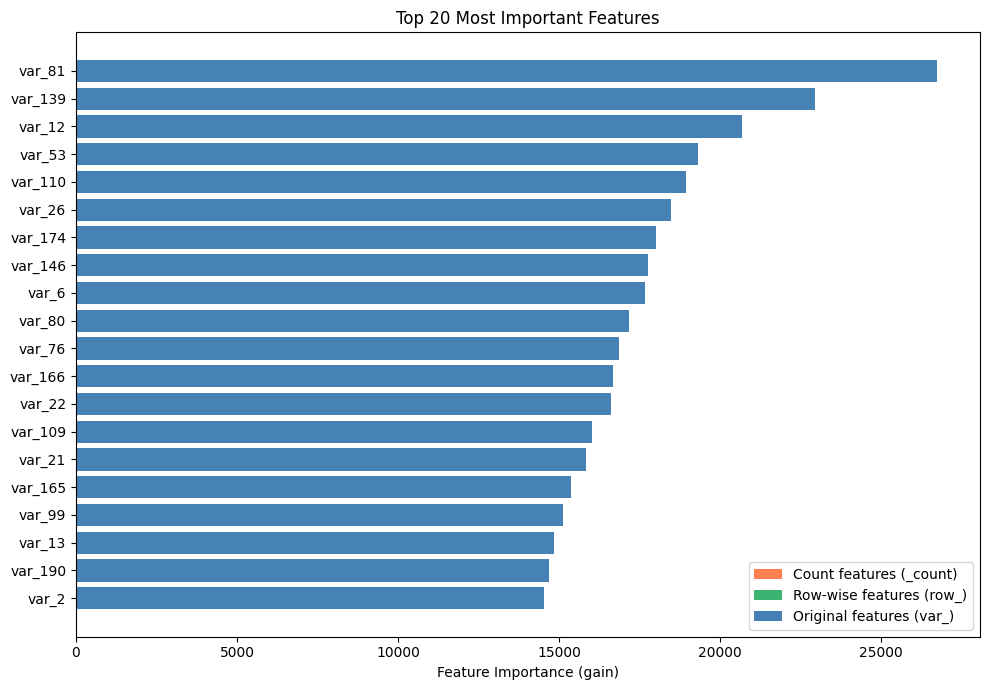

Top 10 features:
feature   importance
 var_81 26738.086268
var_139 22960.740122
 var_12 20689.938165
 var_53 19319.678719
var_110 18940.153965
 var_26 18463.547016
var_174 17999.316530
var_146 17762.402971
  var_6 17658.621259
 var_80 17163.293391


In [21]:
# Train on full data for importance plot
dtrain_full = lgb.Dataset(X_train, label=y_train)
model_full  = lgb.train(
    best_params, dtrain_full,
    num_boost_round=1864  # best iter del fold 1
)

importances = pd.DataFrame({
    'feature'   : all_cols,
    'importance': model_full.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

# Top 20
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral' if '_count' in f else
          'mediumseagreen' if f.startswith('row_') else
          'steelblue' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Most Important Features')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral',        label='Count features (_count)'),
    Patch(facecolor='mediumseagreen', label='Row-wise features (row_)'),
    Patch(facecolor='steelblue',    label='Original features (var_)')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.head(10).to_string(index=False))

---
## 8. Multi-Seed Blending

We run the same 5-fold CV with two additional seeds and average the predictions.
This reduces variance from the random fold splits and typically improves the Kaggle score.

In [22]:
print('=== LightGBM — 5-Fold CV (Seed 0) ===')
best_params['random_state'] = 0
oof_0, test_0, auc_0, _ = run_lgbm_cv(
    X_train, y_train, X_test, best_params, n_folds=N_FOLDS, seed=0
)

print('\n=== LightGBM — 5-Fold CV (Seed 2024) ===')
best_params['random_state'] = 2024
oof_2024, test_2024, auc_2024, _ = run_lgbm_cv(
    X_train, y_train, X_test, best_params, n_folds=N_FOLDS, seed=2024
)

# Blend
oof_blend  = (oof_42 + oof_0 + oof_2024) / 3
test_blend = (test_42 + test_0 + test_2024) / 3

blend_auc = roc_auc_score(y_train, oof_blend)
print(f'\n=== Blended OOF AUC (3 seeds): {blend_auc:.4f} ===')
print(f'  Seed 42  : {auc_42:.4f}')
print(f'  Seed 0   : {auc_0:.4f}')
print(f'  Seed 2024: {auc_2024:.4f}')

=== LightGBM — 5-Fold CV (Seed 0) ===
  Fold 1/5 — AUC: 0.9067  (best iter: 2000)
  Fold 2/5 — AUC: 0.9085  (best iter: 1940)
  Fold 3/5 — AUC: 0.9091  (best iter: 2000)
  Fold 4/5 — AUC: 0.9072  (best iter: 1976)
  Fold 5/5 — AUC: 0.9049  (best iter: 1991)

OOF AUC: 0.9073 ± 0.0014

=== LightGBM — 5-Fold CV (Seed 2024) ===
  Fold 1/5 — AUC: 0.9083  (best iter: 1999)
  Fold 2/5 — AUC: 0.9062  (best iter: 1465)
  Fold 3/5 — AUC: 0.9017  (best iter: 1822)
  Fold 4/5 — AUC: 0.9088  (best iter: 1986)
  Fold 5/5 — AUC: 0.9084  (best iter: 2000)

OOF AUC: 0.9059 ± 0.0027

=== Blended OOF AUC (3 seeds): 0.9101 ===
  Seed 42  : 0.9070
  Seed 0   : 0.9073
  Seed 2024: 0.9059


In [23]:
# Blend de 3 seeds
test_blend = (test_42 + test_0 + test_2024) / 3
final_test_preds = np.clip(test_blend, 0, 1)

submission = pd.DataFrame({
    'ID_code': test['ID_code'],
    'target' : final_test_preds
})
submission.to_csv('submission_lgbm_blend3.csv', index=False)

assert submission.shape[0] == 200_000
assert submission['target'].between(0, 1).all()
assert submission['target'].notna().all()

print('✅ submission_lgbm_blend3.csv generated')
print(submission.head())

✅ submission_lgbm_blend3.csv generated
  ID_code    target
0  test_0  0.020342
1  test_1  0.100570
2  test_2  0.092380
3  test_3  0.074890
4  test_4  0.012493


---
## 9. Pseudo-Labeling

We use the blended test predictions to assign pseudo-labels to high-confidence test rows,
then retrain including those rows as additional training data.

**Only real test rows receive pseudo-labels** — synthetic rows are excluded to avoid
corrupting the training signal.

**Thresholds:** label=1 if prediction > 0.95, label=0 if prediction < 0.05.
These conservative thresholds ensure only very confident predictions are used.

In [24]:
# Assign pseudo-labels to real test rows only
THRESH_POS = 0.95
THRESH_NEG = 0.05

real_test_preds = test_blend[test_real_mask]
pseudo_pos_mask = real_test_preds > THRESH_POS
pseudo_neg_mask = real_test_preds < THRESH_NEG

print(f'Pseudo-label positives (pred > {THRESH_POS}): {pseudo_pos_mask.sum():,}')
print(f'Pseudo-label negatives (pred < {THRESH_NEG}): {pseudo_neg_mask.sum():,}')
print(f'Total pseudo-labeled rows: {pseudo_pos_mask.sum() + pseudo_neg_mask.sum():,}')

Pseudo-label positives (pred > 0.95): 380
Pseudo-label negatives (pred < 0.05): 84,086
Total pseudo-labeled rows: 84,466


In [25]:
# Build augmented training set
real_test_X = X_test[test_real_mask]

X_pseudo = np.vstack([
    real_test_X[pseudo_pos_mask],
    real_test_X[pseudo_neg_mask]
])
y_pseudo = np.concatenate([
    np.ones(pseudo_pos_mask.sum()),
    np.zeros(pseudo_neg_mask.sum())
])

X_train_aug = np.vstack([X_train, X_pseudo])
y_train_aug = np.concatenate([y_train, y_pseudo])

print(f'Original train size : {len(X_train):,}')
print(f'Augmented train size: {len(X_train_aug):,} (+{len(X_pseudo):,} pseudo-labeled rows)')

Original train size : 200,000
Augmented train size: 284,466 (+84,466 pseudo-labeled rows)


In [ ]:
# Retrain with pseudo-labels (3 seeds, blend)
print('=== LightGBM + Pseudo-labels — 5-Fold CV ===')

test_pseudo_blend = np.zeros(len(X_test))
oof_pseudo_list   = []

for seed in [42, 0, 2024]:
    best_params['random_state'] = seed
    print(f'\nSeed {seed}:')
    oof_p, test_p, auc_p, _ = run_lgbm_cv(
        X_train_aug, y_train_aug, X_test,
        best_params, n_folds=N_FOLDS, seed=seed
    )
    # OOF only over original train rows for fair evaluation
    oof_original = oof_p[:len(X_train)]
    oof_auc_orig = roc_auc_score(y_train, oof_original)
    print(f'  OOF AUC (original rows only): {oof_auc_orig:.4f}')
    oof_pseudo_list.append(oof_original)
    test_pseudo_blend += test_p / 3

oof_pseudo_final = np.mean(oof_pseudo_list, axis=0)
pseudo_final_auc = roc_auc_score(y_train, oof_pseudo_final)
print(f'\n=== Pseudo-label blended OOF AUC: {pseudo_final_auc:.4f} ===')

=== LightGBM + Pseudo-labels — 5-Fold CV ===

Seed 42:
  Fold 1/5 — AUC: 0.9171  (best iter: 1949)


In [ ]:
# Compare: with vs without pseudo-labels
print('=== Comparison ===')
print(f'Without pseudo-labels: {blend_auc:.4f}')
print(f'With pseudo-labels   : {pseudo_final_auc:.4f}')
print()

# Choose best
if pseudo_final_auc > blend_auc:
    final_test_preds = test_pseudo_blend
    print('→ Using pseudo-label predictions for submission.')
else:
    final_test_preds = test_blend
    print('→ Pseudo-labels did not help. Using original blend for submission.')

---
## 10. Submission

In [ ]:
final_test_preds = np.clip(final_test_preds, 0, 1)

submission = pd.DataFrame({
    'ID_code': test['ID_code'],
    'target' : final_test_preds
})
submission.to_csv('submission_lgbm.csv', index=False)

assert submission.shape[0] == 200_000
assert submission['target'].between(0, 1).all()
assert submission['target'].notna().all()

print('✅ submission_lgbm.csv generated')
print(f'Shape: {submission.shape}')
print(submission.head())

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(final_test_preds, bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('Predicted probability (target = 1)')
ax.set_ylabel('Number of test samples')
ax.set_title('Distribution of predicted probabilities — LightGBM')
plt.tight_layout()
plt.show()